<h3>Created by: Christopher Kuan
<h3>Date: 16/5/2026

<h1> TSP QAOA timeslot based representation

# Setup

In [1]:
import matplotlib.pyplot as plt
from rustworkx.visualization import mpl_draw as draw_graph
import networkx as nx
import numpy as np
from scipy.optimize import minimize

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_optimization.applications import Tsp
from qiskit_optimization.converters import QuadraticProgramToQubo

from qiskit_aer import AerSimulator

from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals

import math
import time

# Arguments

In [2]:
# General
n = 3                   # number of nodes
node_color = "r"        # color of node, "r" - red, "b" - blue, "g" - green, "y" - yellow, "m" - magenta
penalty_weight = 280    # Good practice is max coeeficient * number of qubits

# Simple QAOA
algorithm_globals_random_seed = 10598
state_vector_sampler_seed = 42
p_layer_simple = 2      # number of layers of QAOA (simple)

# Advanced QAOA
p_layer_advanced = 3   # number of layers of QAOA (advanced)
initial_gamma = 0.1
initial_beta = 0.5
method="COBYQA"         # type of classical solver for QAOA
tol=1e-3                # tolerance for termination

# Helper functions

In [3]:
def draw_graph(G, colors, pos):
    ax = plt.axes(frameon=True)
    nx.draw_networkx(G, node_color=colors, node_size=600, alpha=0.8, ax=ax, pos=pos)
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)
    
def normalize_hamiltonian(cost_hamiltonian):
    coeffs = np.abs(cost_hamiltonian.coeffs)
    scale = np.max(coeffs)
    return cost_hamiltonian / scale

def check_feasibility (bitstring):
    # Split into even parts
    bit_list = [bitstring[i:i+n] for i in range(0, num_qubits, n)]
    
    # Check if each part has only one 1 and the positions do not overlap
    position_history = []
    for bits in bit_list:
        if bits.count('1') != 1:
            return 1
        else:
            position = bits.find('1')
            if position in position_history:
                return 1
            position_history.append(position)
    return 0

def filter_result(eigenstate):
    sorted_eigenstate = sorted(eigenstate.items(), key=lambda x: x[1], reverse=True)

    invalid_index = []
    for i in range(len(sorted_eigenstate)):
        if check_feasibility(sorted_eigenstate[i][0]) == 1:
            invalid_index.append(i)
    
    invalid_index = invalid_index[::-1]
    
    for i in invalid_index:        
        sorted_eigenstate.pop(i)
    
    return sorted_eigenstate

def plot_result_distribution(eigenstate, top=5):
    if len(eigenstate) < top:
        raise ValueError("Top value exceed amount of valid results")
    
    top_results = eigenstate[:top]
    
    # Plot result
    x = [result[0] for result in top_results]
    y = [result[1] for result in top_results]
    plt.figure(figsize=(10,6))
    bars = plt.bar(list(x), list(y), color="tab:grey")
    plt.title("Result distribution")
    plt.xlabel("Bitstrings (X_n,...,X_0)")
    plt.xticks(rotation=45)
    plt.ylabel("Probability")
    if top < 4:
        maxpurple = math.floor(top/2)
    else:
        maxpurple = 4
    for i in range(maxpurple):
        bars[i].set_color("tab:purple")
    plt.show()

def show_path(eigenstate, cost_matrix):
    bitstring = eigenstate[0][0][::-1]
    bit_list = [bitstring[i:i+n] for i in range(0, num_qubits, n)]
    
    # Find the time at which the salesman is at each node
    time_list = []
    for bit in bit_list:
        time_list.append(bit.find('1'))
    
    # Construct the path
    path = [None] * n
    node_count = 0
    for time in time_list:
        path[time] = node_count
        node_count += 1
    
    # Printing result
    print("Optimal path")
    for node in path:
        print(node, "-->", end=" ")
    print(path[0])
    
    # Finding cost
    cost = 0
    path.insert(len(path), path[0])
    for node in range(0, len(path)-1):
        cost += cost_matrix[path[node]][path[node+1]]
        print(path[node], path[node+1])
    return cost

# Getting graph

distance
 [[ 0. 60. 73.]
 [60.  0. 87.]
 [73. 87.  0.]]


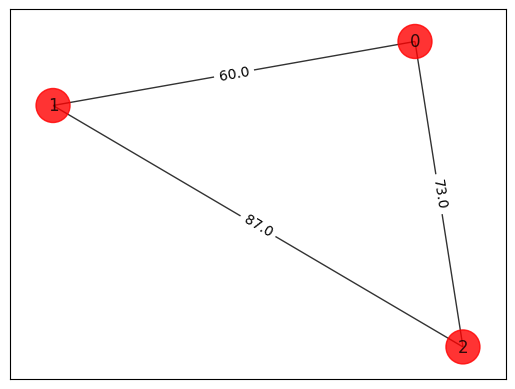

In [4]:
num_qubits = n**2
tsp = Tsp.create_random_instance(n, seed=561)
cost_matrix = nx.to_numpy_array(tsp.graph)
print("distance\n", cost_matrix)

colors = [node_color for node in tsp.graph.nodes]
pos = [tsp.graph.nodes[node]['pos'] for node in tsp.graph.nodes]
draw_graph(tsp.graph, colors, pos)

# Simple method (Using Qiskit built-in functions)
## Converting to QUBO then Ising Hamiltonian

In [5]:
# Framing TSP into objective functions and constraints
qp = tsp.to_quadratic_program()
print("######### QUADRATIC FUNCTION #########")
print(qp.prettyprint())

# Converting to QUBO
qp2qubo = QuadraticProgramToQubo(penalty_weight)
qubo = qp2qubo.convert(qp)

# Converting to Ising
simple_op, offset = qubo.to_ising()
print("\n\n######### ISING HAMILTONIAN #########")
print("Offset:", offset)
print("Ising Hamiltonian:")
print(str(simple_op))

# Normalizing Hamiltonian
normalized_simple_op = normalize_hamiltonian(simple_op)
print("\n\n\n######### NORMALIZED ISING HAMILTONIAN #########")
print(normalized_simple_op)

######### QUADRATIC FUNCTION #########
Problem name: TSP

Minimize
  60*x_0_0*x_1_1 + 60*x_0_0*x_1_2 + 73*x_0_0*x_2_1 + 73*x_0_0*x_2_2
  + 60*x_0_1*x_1_0 + 60*x_0_1*x_1_2 + 73*x_0_1*x_2_0 + 73*x_0_1*x_2_2
  + 60*x_0_2*x_1_0 + 60*x_0_2*x_1_1 + 73*x_0_2*x_2_0 + 73*x_0_2*x_2_1
  + 87*x_1_0*x_2_1 + 87*x_1_0*x_2_2 + 87*x_1_1*x_2_0 + 87*x_1_1*x_2_2
  + 87*x_1_2*x_2_0 + 87*x_1_2*x_2_1

Subject to
  Linear constraints (6)
    x_0_0 + x_0_1 + x_0_2 == 1  'c0'
    x_1_0 + x_1_1 + x_1_2 == 1  'c1'
    x_2_0 + x_2_1 + x_2_2 == 1  'c2'
    x_0_0 + x_1_0 + x_2_0 == 1  'c3'
    x_0_1 + x_1_1 + x_2_1 == 1  'c4'
    x_0_2 + x_1_2 + x_2_2 == 1  'c5'

  Binary variables (9)
    x_0_0 x_0_1 x_0_2 x_1_0 x_1_1 x_1_2 x_2_0 x_2_1 x_2_2



######### ISING HAMILTONIAN #########
Offset: 2010.0
Ising Hamiltonian:
SparsePauliOp(['IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII', 'IIIIIIIZZ', 'IIIIIIZIZ', 'IIIIIZIIZ', 'IIIIZIIIZ', 'IIIZIIIIZ', 'IIZII

## Defining sampler, optimizer then train the QAOA

In [6]:
"""
Sampler's job is to run the quantum circuit, measure probabilities or bitstrings,
and return sampling results
Assumes:
- exact statevector simulation
- noiseless
- no real hardware execution

optimizer is the classical optimizer that QAOA uses
"""

# Store loss values
loss_history = []
param_history = []

def callback(eval_count, params, value, metadata):
    """Callback function to track optimization progress"""
    loss_history.append(value)
    param_history.append(params)
    
algorithm_globals.random_seed = algorithm_globals_random_seed
sampler = StatevectorSampler()
optimizer = COBYLA()
simple_start_time = time.time()
qaoa = QAOA(sampler=sampler, optimizer=optimizer, reps=p_layer_simple, callback=callback)
result = qaoa.compute_minimum_eigenvalue(normalized_simple_op)
simple_end_time = time.time()
simple_runtime = simple_end_time - simple_start_time

c:\Users\kjh\Desktop\VRPTW\Coding\venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\kjh\Desktop\VRPTW\Coding\venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\kjh\Desktop\VRPTW\Coding\venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


## Visualizing result

QAOA runtime: 119.6262 seconds


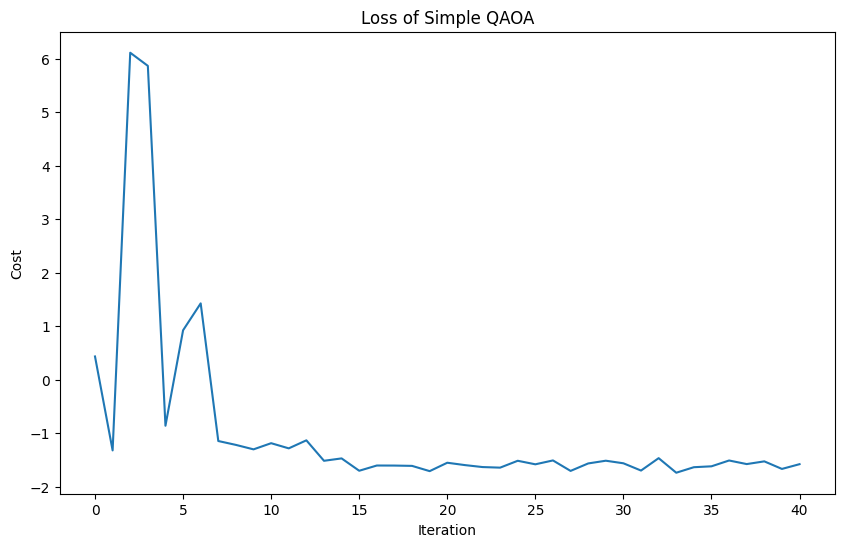

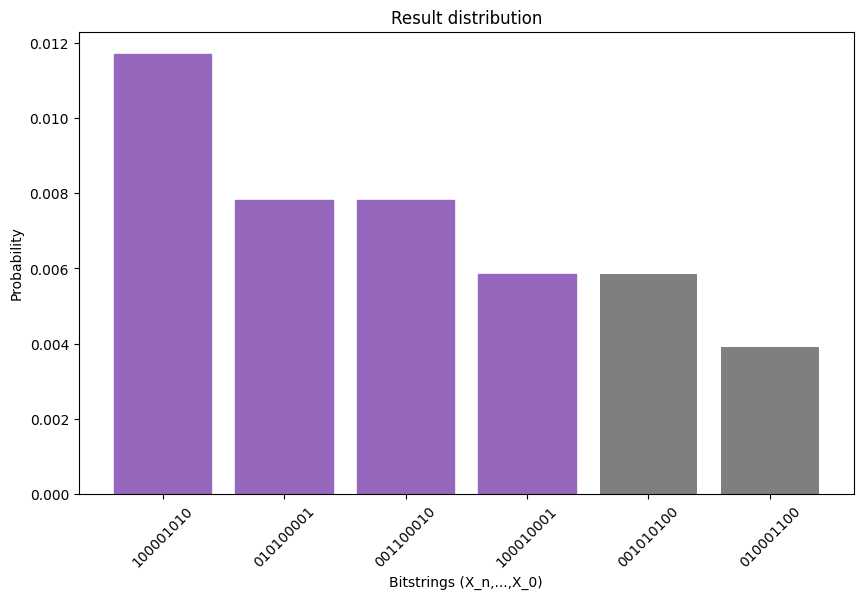

Optimal path
1 --> 0 --> 2 --> 1
1 0
0 2
2 1


np.float64(220.0)

In [7]:
# Reporting runtime
print(f"QAOA runtime: {simple_runtime:.4f} seconds")

# Plotting loss function
plt.figure(figsize=(10,6))
plt.plot(loss_history)
plt.title("Loss of Simple QAOA")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

filtered_sorted_eigenstate = filter_result(result.eigenstate)
maxlen = len(filtered_sorted_eigenstate)
if maxlen >10:
    maxlen = 10
plot_result_distribution(filtered_sorted_eigenstate, top=maxlen)
show_path(filtered_sorted_eigenstate, cost_matrix)

# Advanced method (Constructing own Hamiltonian and QAOA)
## Constructing Ising Hamiltonian

In [8]:
def build_paulis(cost_matrix, penalty, n) -> list[tuple[str, list[int], float]]:
    pauli_list = []
    # Make a list of tuples that has ("gate type", [which qubit it corresponds to], coeff)
    row, col = cost_matrix.shape
    
    # Build linear terms
    for i in range(row):
        for j in range(col):
            weight = sum(cost_matrix[i][:]) * -0.5 + penalty*(2-n)
            pauli_list.append(("Z", [i*n+j], weight))
  
    # Build quadratic terms
    for i in range(row*col):
        for j in range(i+1, row*col):
            from_node = int(math.floor(i / n))
            from_time = int(i % n)
            to_node = int(math.floor(j / n))
            to_time = int(j % n)
            weight = 0
            weight = cost_matrix[from_node][to_node] * 0.25 * int(from_time != to_time) + penalty / 2 * int(from_node == to_node) + penalty / 2 * int(from_time == to_time)
            pauli_list.append(("ZZ", [i, j], weight))
            
    return pauli_list

pauli_list = build_paulis(cost_matrix=cost_matrix, penalty=penalty_weight, n=n)
cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=num_qubits)
normalized_hamiltonian = normalize_hamiltonian(cost_hamiltonian)
print("Cost Function Hamiltonian:", normalized_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII', 'IIIIIIIZZ', 'IIIIIIZIZ', 'IIIIIZIIZ', 'IIIIZIIIZ', 'IIIZIIIIZ', 'IIZIIIIIZ', 'IZIIIIIIZ', 'ZIIIIIIIZ', 'IIIIIIZZI', 'IIIIIZIZI', 'IIIIZIIZI', 'IIIZIIIZI', 'IIZIIIIZI', 'IZIIIIIZI', 'ZIIIIIIZI', 'IIIIIZZII', 'IIIIZIZII', 'IIIZIIZII', 'IIZIIIZII', 'IZIIIIZII', 'ZIIIIIZII', 'IIIIZZIII', 'IIIZIZIII', 'IIZIIZIII', 'IZIIIZIII', 'ZIIIIZIII', 'IIIZZIIII', 'IIZIZIIII', 'IZIIZIIII', 'ZIIIZIIII', 'IIZZIIIII', 'IZIZIIIII', 'ZIIZIIIII', 'IZZIIIIII', 'ZIZIIIIII', 'ZZIIIIIII'],
              coeffs=[-0.9625    +0.j, -0.9625    +0.j, -0.9625    +0.j, -0.98194444+0.j,
 -0.98194444+0.j, -0.98194444+0.j, -1.        +0.j, -1.        +0.j,
 -1.        +0.j,  0.38888889+0.j,  0.38888889+0.j,  0.38888889+0.j,
  0.04166667+0.j,  0.04166667+0.j,  0.38888889+0.j,  0.05069444+0.j,
  0.05069444+0.j,  0.38888889+0.j,  0.04166667+0.j,  0.38888889+0.j,
  0.04

## Constructing QAOA

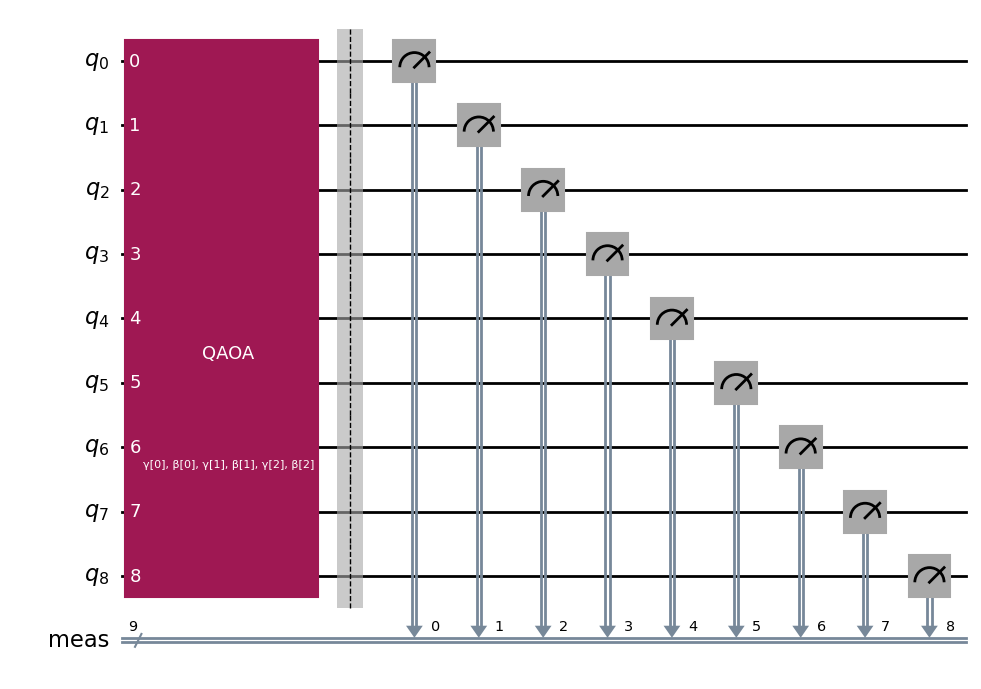

In [9]:
circuit = QAOAAnsatz(cost_operator=normalized_hamiltonian, reps=p_layer_advanced)
circuit.measure_all()

# Show circuit
circuit.draw("mpl")

## Setting up training

In [10]:
##### Simulator #####
backend = AerSimulator()
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
candidate_circuit = pm.run(circuit)
# candidate_circuit.draw("mpl", fold=False, idle_wires=False)

# Initial parameters
init_params = [initial_beta] * p_layer_advanced + [initial_gamma] * p_layer_advanced

# Objective function to minimize.
def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)    
    pub = (ansatz, isa_hamiltonian, params)

    job = estimator.run([pub])
    
    results = job.result()[0]
    cost = results.data.evs
    
    objective_func_vals.append(cost)
    
    return cost

## Training QAOA

In [11]:
objective_func_vals = [] # Global variable

advanced_start_time = time.time()
# Training
with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000
    
    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    
    # Scipy minimize routine, minimize function does Minimization of scalar 
    # function of one or more variables.
    result = minimize(
        cost_func_estimator, # Objective function to be minimized
        init_params, # initial guess
        args=(candidate_circuit, normalized_hamiltonian, estimator), # extra arguments passed to the objective function and its derivatives
        method=method, # type of solver
        tol=tol, # tolerance for termination
    )
    
# Final loop to get result
optimized_circuit = candidate_circuit.assign_parameters(result.x)

sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
advanced_end_time = time.time()
advanced_runtime = advanced_end_time - advanced_start_time

c:\Users\kjh\Desktop\VRPTW\Coding\venv\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


## Visualizing result

QAOA runtime: 3.1716 seconds


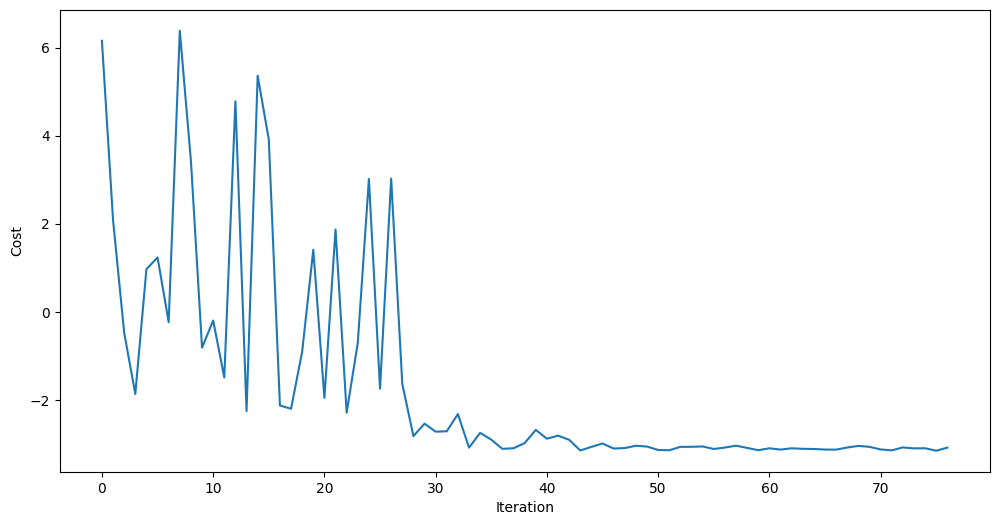

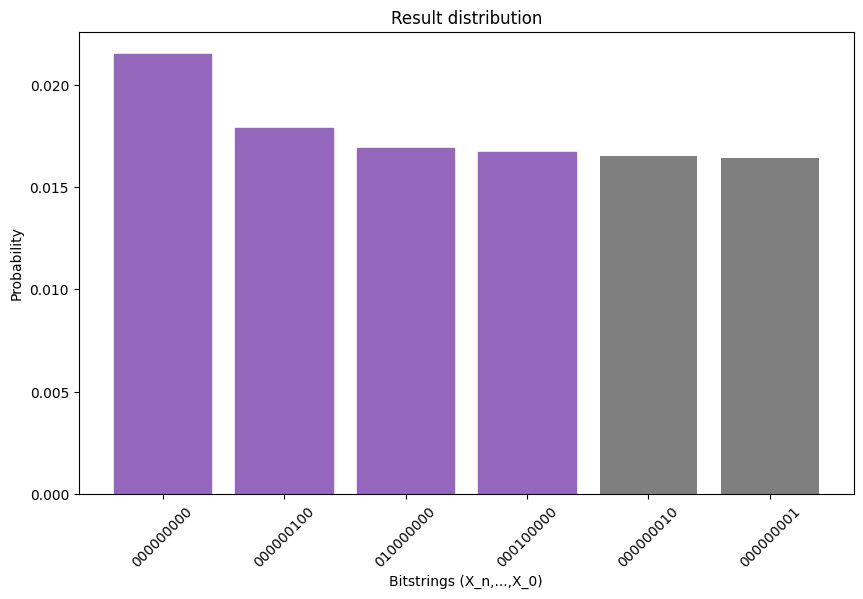

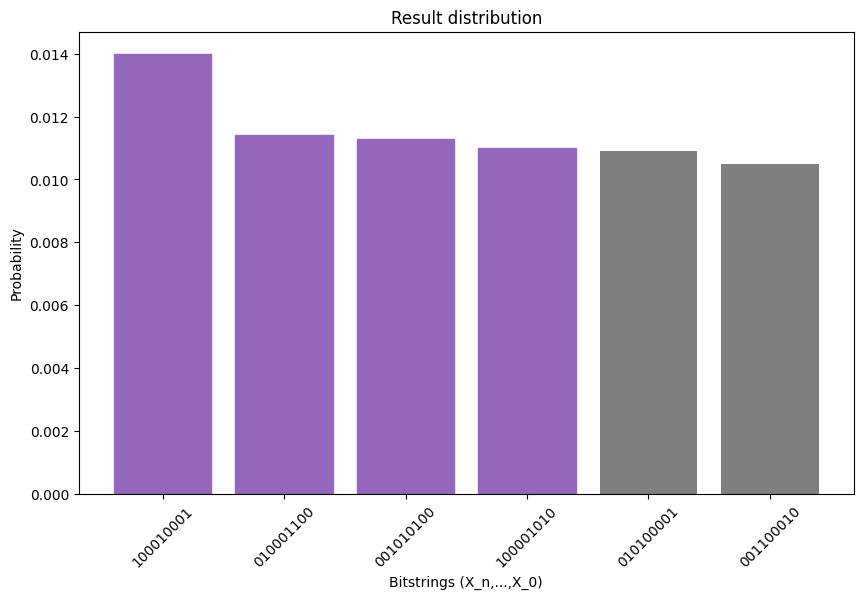

Optimal path
0 --> 1 --> 2 --> 0
0 1
1 2
2 0
Cost:  220.0


In [12]:
# Reporting runtime
print(f"QAOA runtime: {advanced_runtime:.4f} seconds")

plt.figure(figsize=(12,6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

filtered_sorted_eigenstate = filter_result(final_distribution_bin)
sorted_eigenstate = sorted(final_distribution_bin.items(), key=lambda x: x[1], reverse=True)

maxlen = len(filtered_sorted_eigenstate)
if maxlen >10:
    maxlen = 10
plot_result_distribution(sorted_eigenstate, top=maxlen)
plot_result_distribution(filtered_sorted_eigenstate, top=maxlen)
cost = show_path(filtered_sorted_eigenstate, cost_matrix)
print("Cost: ", cost)